# Pattern Projection — decompose surface moves onto desk patterns

Given a set of hand-drawn patterns (from `pattern_creator.py`), decompose every day's surface *move* into exposures on those patterns. `factors.project_onto_patterns(target, patterns, method=...)` is the workhorse. Each day's panel is regressed cross-sectionally on the K patterns; one row of exposures per date comes out.

When patterns share support (i.e. are correlated as vectors in cell-space), OLS exposures get unstable. The interface dispatches over four methods so you can A/B test:

| method | when to reach for it |
|---|---|
| `ols` | patterns are roughly orthogonal — default |
| `ridge` | patterns are correlated; want smooth, stable exposures |
| `nnls` | exposures must be non-negative (one-sided shocks) |
| `lasso` | many candidate patterns, want sparsity (most exposures = 0) |

All analysis below is on **daily diffs** — we project *moves*, not levels.

## 0. Setup

In [1]:
import sys
sys.path.insert(0, "..")
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pca import load_long, to_wide, EXPIRY_LABELS, TENOR_LABELS
from factors import project_onto_patterns

sns.set_theme(style="whitegrid")

rate  = to_wide(load_long("../data/mock/rate.pkl")).diff().dropna()
vol   = to_wide(load_long("../data/mock/atm_vol.pkl")).diff().dropna()
skew  = to_wide(load_long("../data/mock/skew_p2.pkl")).diff().dropna()

priors_path = Path("../data/priors.pkl")
if not priors_path.exists():
    raise FileNotFoundError(
        f"{priors_path.resolve()} not found — run `streamlit run "
        f"pattern_creator.py` and click Save first."
    )
priors = pd.read_pickle(priors_path).reindex(columns=vol.columns, fill_value=0.0)
print(f"vol diff: {vol.shape}   priors: {priors.shape}   names: {list(priors.index)}")

def cell_grid(series):
    return series.unstack("tenor").reindex(
        index=[e for e in EXPIRY_LABELS if e in vol.columns.get_level_values("expiry")],
        columns=[t for t in TENOR_LABELS if t in vol.columns.get_level_values("tenor")],
    )

vol diff: (499, 204)   priors: (3, 204)   names: ['pattern_1', 'diag_band_2', 'diag_band_3']


## 1. Inspect the patterns

Each pattern is one row of the saved DataFrame — a vector over `(expiry, tenor)` cells. Heatmap them, then look at their pairwise cell-space correlation (`pattern_corr`). This is the *intrinsic* correlation of the patterns; the exposure correlation we get from projection can be different (Section 2 makes that point).

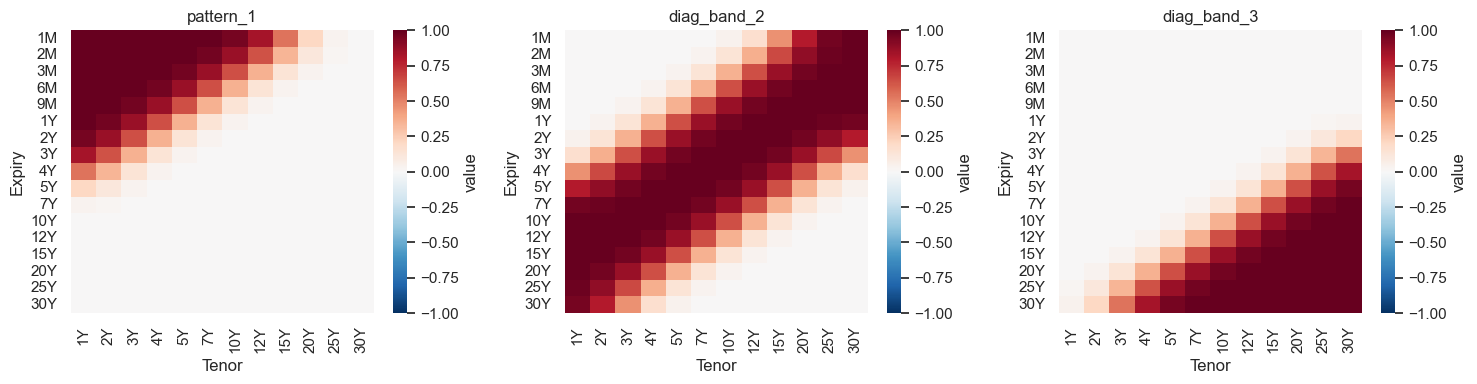


pattern_corr (intrinsic, in centered cell-space):
             pattern_1  diag_band_2  diag_band_3
pattern_1        1.000       -0.500       -0.403
diag_band_2     -0.500        1.000       -0.591
diag_band_3     -0.403       -0.591        1.000


In [2]:
K = len(priors)
fig, axes = plt.subplots(1, K, figsize=(5 * K, 4))
if K == 1: axes = [axes]
vmax = float(priors.abs().max().max())
for ax, name in zip(axes, priors.index):
    sns.heatmap(cell_grid(priors.loc[name]), ax=ax, cmap="RdBu_r",
                center=0, vmin=-vmax, vmax=vmax,
                cbar_kws={"label": "value"})
    ax.set_title(name); ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

# pattern_corr falls out of any projection; cheapest to grab it from a dummy OLS call.
pcorr = project_onto_patterns(vol.iloc[:5], priors, method="ols")["pattern_corr"]
print("\npattern_corr (intrinsic, in centered cell-space):")
print(pcorr.round(3))

## 2. OLS projection on vol diff — and the multicollinearity problem

Run the simplest method. Then notice the gap: `pattern_corr` is mildly **negative** (patterns are roughly complementary in cell-space), but `exposure_corr` is strongly **positive** — every day, all three patterns get similar exposures. That's the multicollinearity hint: a single common driver in the vol-diff panel (mostly level moves) is being distributed across the three patterns because no single one captures it cleanly.

The `condition_number` of `P P^T` is the formal diagnostic. Under ~10² is comfortable for OLS; > ~10⁶ means switch to ridge.

method = ols
  r2_total         = 0.1904
  condition number = 1.41  (PP^T)

exposure_corr (across dates):
             pattern_1  diag_band_2  diag_band_3
pattern_1        1.000        0.911        0.906
diag_band_2      0.911        1.000        0.915
diag_band_3      0.906        0.915        1.000

pattern_corr  (intrinsic) — same as Section 1, for contrast:
             pattern_1  diag_band_2  diag_band_3
pattern_1        1.000       -0.500       -0.403
diag_band_2     -0.500        1.000       -0.591
diag_band_3     -0.403       -0.591        1.000


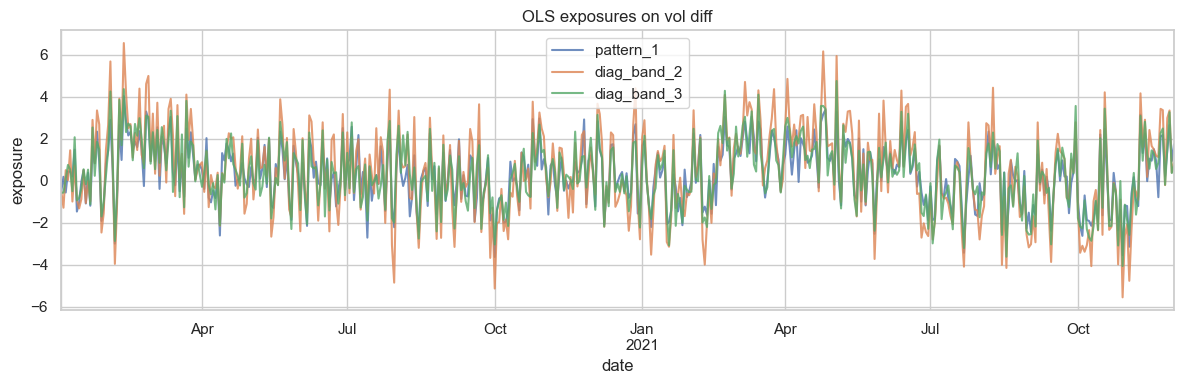

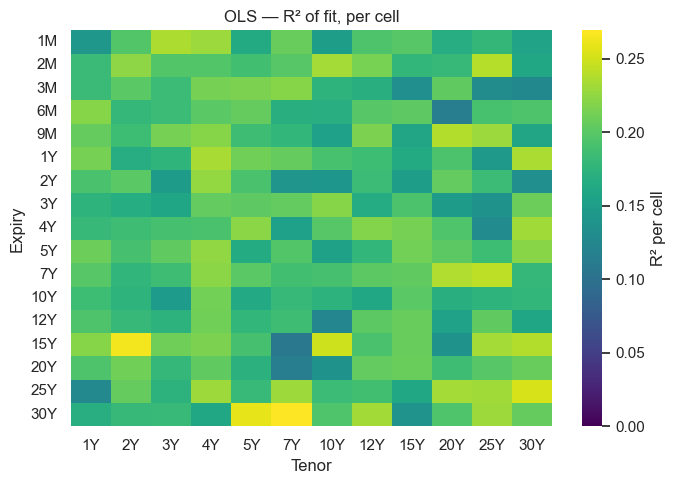

In [3]:
res_ols = project_onto_patterns(vol, priors, method="ols")
print(f"method = ols")
print(f"  r2_total         = {res_ols['r2_total']:.4f}")
print(f"  condition number = {res_ols['condition_number']:.3g}  (PP^T)")
print()
print("exposure_corr (across dates):")
print(res_ols["exposure_corr"].round(3))
print()
print("pattern_corr  (intrinsic) — same as Section 1, for contrast:")
print(res_ols["pattern_corr"].round(3))

# Exposure time series.
fig, ax = plt.subplots(figsize=(12, 4))
res_ols["exposures"].plot(ax=ax, alpha=0.8)
ax.set_title("OLS exposures on vol diff")
ax.set_xlabel("date"); ax.set_ylabel("exposure")
plt.tight_layout(); plt.show()

# R² per cell.
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(cell_grid(res_ols["r2_per_cell"]), ax=ax, cmap="viridis",
            vmin=0, vmax=float(res_ols["r2_per_cell"].max()),
            cbar_kws={"label": "R² per cell"})
ax.set_title("OLS — R² of fit, per cell"); ax.set_xlabel("Tenor"); ax.set_ylabel("Expiry")
plt.tight_layout(); plt.show()

## 3. Method comparison — same target, same patterns

Run all four methods on `vol`. Compare:

* **`r2_total`** — fit quality. OLS wins by construction (least-squares optimum); the others trade fit for stability / sparsity / constraints.
* **`max|exposure_corr| off-diag`** — how correlated the resulting exposure time series are. Smaller is better — it means the method actually distinguishes the patterns.
* **`mean(|exposure|)`** — the typical magnitude of exposures across all dates/patterns. Big spikes suggest noise blowing up.
* **`#zero exposures`** — for lasso/nnls, how often a pattern is fully suppressed.

method  r2_total  max|exposure_corr|  mean|exposure|  #zero exposures
   ols    0.1904              0.9152          1.3984                0
 ridge    0.1495              0.9356          0.7501                0
  nnls    0.1266              0.8938          0.8782              638
 lasso    0.1545              0.8788          0.6820              610


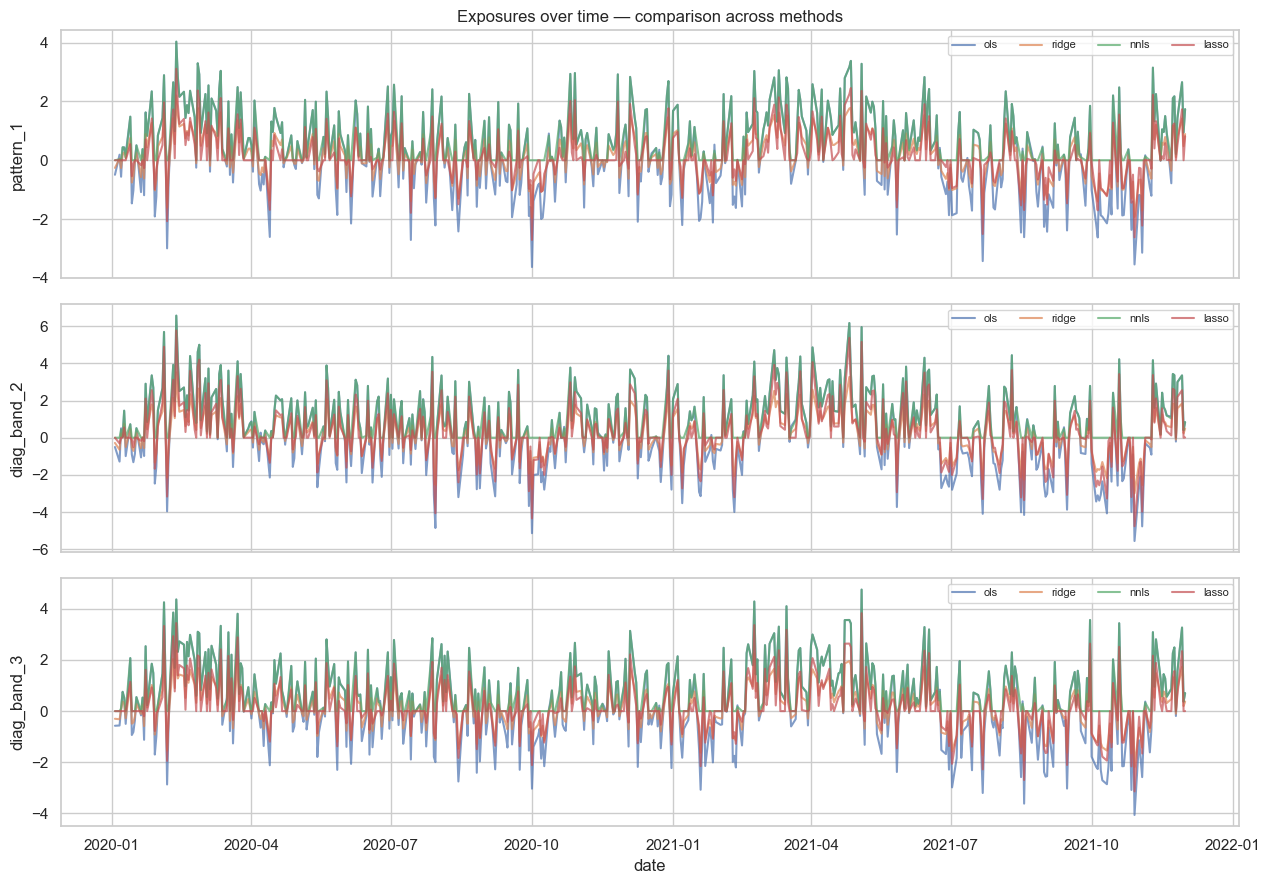

In [4]:
method_kwargs = {
    "ols":   {},
    "ridge": {"ridge_alpha": 1.0},
    "nnls":  {},
    "lasso": {"lasso_alpha": 0.005},
}
results = {m: project_onto_patterns(vol, priors, method=m, **kw)
           for m, kw in method_kwargs.items()}

rows = []
for m, r in results.items():
    ec = r["exposure_corr"].values
    off = np.abs(ec - np.eye(len(ec)))
    rows.append({
        "method":             m,
        "r2_total":           r["r2_total"],
        "max|exposure_corr|": float(off.max()),
        "mean|exposure|":     float(r["exposures"].abs().mean().mean()),
        "#zero exposures":    int((r["exposures"].abs() < 1e-9).sum().sum()),
    })
summary = pd.DataFrame(rows)
print(summary.round(4).to_string(index=False))

# Exposure time series — all four methods side-by-side, one row per pattern.
fig, axes = plt.subplots(K, 1, figsize=(13, 3 * K), sharex=True)
if K == 1: axes = [axes]
for j, name in enumerate(priors.index):
    for m, r in results.items():
        axes[j].plot(r["exposures"].index, r["exposures"][name],
                     label=m, alpha=0.7)
    axes[j].set_ylabel(name); axes[j].legend(loc="upper right", ncol=4, fontsize=8)
axes[-1].set_xlabel("date")
axes[0].set_title("Exposures over time — comparison across methods")
plt.tight_layout(); plt.show()

## 4. Ridge `alpha` sweep — the fit-vs-stability frontier

`ridge_alpha = 0` is OLS. Larger values shrink exposures and decorrelate them but cost fit quality. Plot the trade-off; pick a knee by eye.

 alpha  r2_total  max|exposure_corr|  mean|exposure|
   0.0    0.1904              0.9152          1.3984
   0.1    0.1892              0.9194          1.2869
   0.5    0.1731              0.9295          0.9762
   1.0    0.1495              0.9356          0.7501
   2.0    0.1141              0.9411          0.5128
   5.0    0.0649              0.9462          0.2631
  20.0    0.0203              0.9495          0.0766
 100.0    0.0043              0.9506          0.0160


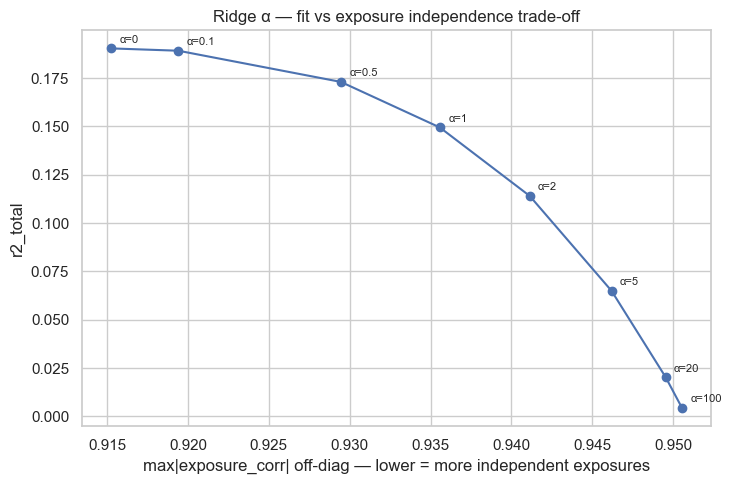

In [5]:
alphas = [0.0, 0.1, 0.5, 1.0, 2.0, 5.0, 20.0, 100.0]
rows = []
for a in alphas:
    r = project_onto_patterns(vol, priors, method="ridge", ridge_alpha=a)
    ec = r["exposure_corr"].values
    off = np.abs(ec - np.eye(len(ec)))
    rows.append({
        "alpha":              a,
        "r2_total":           r["r2_total"],
        "max|exposure_corr|": float(off.max()),
        "mean|exposure|":     float(r["exposures"].abs().mean().mean()),
    })
sweep = pd.DataFrame(rows)
print(sweep.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(sweep["max|exposure_corr|"], sweep["r2_total"], marker="o")
for _, row in sweep.iterrows():
    ax.annotate(f"α={row['alpha']:g}",
                (row["max|exposure_corr|"], row["r2_total"]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)
ax.set_xlabel("max|exposure_corr| off-diag — lower = more independent exposures")
ax.set_ylabel("r2_total")
ax.set_title("Ridge α — fit vs exposure independence trade-off")
plt.tight_layout(); plt.show()

## 5. Same patterns × different surfaces

The patterns were drawn with one application in mind, but the projection is generic. Run the same set against rate diff, vol diff, and skew diff — answers 'do these patterns explain X surface's moves?' for each X.

In [6]:
targets = {"rate": rate, "atm_vol": vol, "skew_p2": skew}
rows = []
for tname, t in targets.items():
    r = project_onto_patterns(t, priors, method="ridge", ridge_alpha=1.0)
    ec = r["exposure_corr"].values
    off = np.abs(ec - np.eye(len(ec)))
    rows.append({
        "target":             tname,
        "r2_total":           r["r2_total"],
        "max|exposure_corr|": float(off.max()),
        "cond(PP^T)":         r["condition_number"],
    })
print("Projection of the same priors onto different surfaces (method=ridge, α=1.0):")
print(pd.DataFrame(rows).round(4).to_string(index=False))

Projection of the same priors onto different surfaces (method=ridge, α=1.0):
 target  r2_total  max|exposure_corr|  cond(PP^T)
   rate    0.0362              0.7199       1.413
atm_vol    0.1495              0.9356       1.413
skew_p2    0.1430              0.9301       1.413


## Notes

* The `pattern_corr` vs `exposure_corr` gap in Section 2 is the diagnostic you actually look at — patterns can be near-orthogonal in cell-space yet still produce strongly correlated exposures if the panel is dominated by one common driver. Ridge or lasso both shrink the resulting correlation.
* For most use cases here, `ridge` with a moderate `alpha` is the safe default. The α sweep in Section 4 is the principled way to pick.
* `nnls` is restrictive on diff data because moves go both directions — only reach for it if your patterns model one-sided shocks.
* `lasso` is most useful when K is large (many candidate patterns); for K ≤ 5 it's mostly a noisy version of ridge.
* Re-running `pattern_creator.py` and saving overwrites `data/priors.pkl` — this notebook needs no edits to pick up new patterns.